In [1]:
%load_ext autoreload
%autoreload 2
import sys
from pathlib import Path

project_root = Path.cwd()
if project_root.name == "notebook":
    project_root = project_root.parent

sys.path.insert(0, str(project_root))
print("project root:", project_root)

from pathlib import Path
from src.datamodule.av2_dataset import Av2Dataset
from src.datamodule.av2_extractor import Av2Extractor
from src.datamodule.av2_dataset import collate_fn
from av2.datasets.motion_forecasting import scenario_serialization
from av2.map.map_api import ArgoverseStaticMap
from src.utils.vis import  visualize_scenario
from src.model.trainer_forecast import Trainer as Model
import torch

data_root = Path("/mnt/datasets/av2_motion_forecasting/val") # Path to the datase
ckpt = "/home/hyk/forecast-mae/outputs/forecast-mae-forecast/2026-06-11/04-17-51/checkpoints/last.ckpt"
dataset = Av2Dataset(data_root=data_root, extractor=Av2Extractor(radius=150))
device = torch.device("cuda:0")
model = Model.load_from_checkpoint(
      ckpt,
      pretrained_weights=None,
      map_location=device,
)
model = model.to(device).eval()



project root: /home/hyk/forecast-mae


/home/anaconda3/envs/forecast_mae_py310/lib/python3.10/site-packages/natten/functional.py:83: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  def forward(
/home/anaconda3/envs/forecast_mae_py310/lib/python3.10/site-packages/natten/functional.py:205: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  def backward(
/home/anaconda3/envs/forecast_mae_py310/lib/python3.10/site-packages/natten/functional.py:261: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  def forward(
/home/anaconda3/envs/forecast_mae_py310/lib/python3.10/site-packages/natten/functional.py:381: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  def backward(
/ho

Extracting data from /mnt/datasets/av2_motion_forecasting/val
data root: /mnt/datasets/av2_motion_forecasting/val/None, total number of files: 24988


/home/anaconda3/envs/forecast_mae_py310/lib/python3.10/site-packages/lightning_fabric/utilities/cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


model device: cuda:0
input device: cuda:0


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


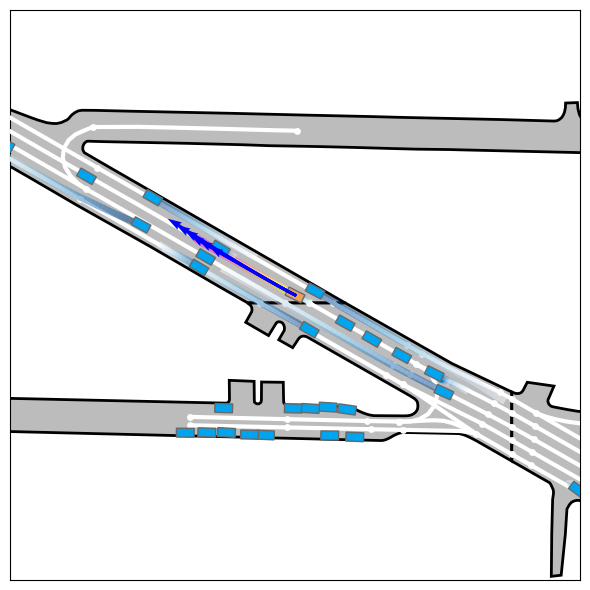

In [8]:
import torch

data = dataset[97]
scene_id = data["scenario_id"]

scene_file = data_root / scene_id / f"scenario_{scene_id}.parquet"
map_file = data_root / scene_id / f"log_map_archive_{scene_id}.json"

scenario = scenario_serialization.load_argoverse_scenario_parquet(scene_file)
static_map = ArgoverseStaticMap.from_json(map_file)

device = next(model.parameters()).device

batch = collate_fn([data])
batch = {
  key: value.to(device) if torch.is_tensor(value) else value
  for key, value in batch.items()
}

print("model device:", device)
print("input device:", batch["x"].device)

with torch.inference_mode():
  prediction, prob = model.predict(batch)

visualize_scenario(
  scenario,
  static_map,
  prediction=prediction.squeeze(0),
)
